In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa


E0000 00:00:1773510188.283004  283779 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773510188.283597  283779 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1773510188.283602  283779 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773510188.283603  283779 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1773510188.283605  283779 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


In [2]:
dataframe_dk = pd.read_csv("DK_2015_merged.csv", index_col = 0, sep = ",", parse_dates=True)
demand_dk = dataframe_dk["DK_load_actual_entsoe_transparency"]
CF_wind = dataframe_dk["wind_cf_Unnamed: 1"]
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"]
dataframe_dk.head()

,DK_load_actual_entsoe_transparency,pv_cf_Unnamed: 1,wind_cf_Unnamed: 1
utc_timestamp,,,
2015-01-01 00:00:00+00:00,3100.00,0.0,0.537323
2015-01-01 01:00:00+00:00,3100.02,0.0,0.557632
2015-01-01 02:00:00+00:00,2980.39,0.0,0.583454
2015-01-01 03:00:00+00:00,2933.49,0.0,0.614832
2015-01-01 04:00:00+00:00,2941.54,0.0,0.644214


In [3]:
annuity_factor = 0.045

data = {
    "capital_cost": [
        1500000 * annuity_factor + 60000,   # wind: 127,500 $/MW/year
        800000 * annuity_factor + 14000,     # solar: 50,000 $/MW/year
        700000 * annuity_factor + 24000,     # CCGT:  55,500 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30]  # CCGT: ~63.4 $/MWh
}

costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])
costs.head()

,capital_cost,marginal_cost
wind_combined,127500.0,0.000000
solar,50000.0,0.000000
CCGT,55500.0,63.371429


Defining Network

In [4]:
dnk_n = pypsa.Network()


In [5]:
dnk_n.set_snapshots(dataframe_dk.index.values)


Adding the first and for now only node/bus ---> Denmark

In [6]:
dnk_n.add("Bus", "Denmark")

Defining carriers (technolgy generators or batteries)

In [7]:
carriers = ["wind_combined", "solar", "CCGT"]
dnk_n.add(
    "Carrier",
    carriers,
    color=["blue","red","brown"],
    )

Demand:

In [8]:
dnk_n.add("Load", "dnk_demand", bus = "Denmark", p_set = demand_dk.values
      )
#Denmark demand associated to the Denmark Bus

In [9]:
max_val = demand_dk.max()
max_time = demand_dk.idxmax()

print(max_val)
print(max_time)

5709.95
2015-01-20 16:00:00+00:00


<Axes: xlabel='snapshot', ylabel='MW'>

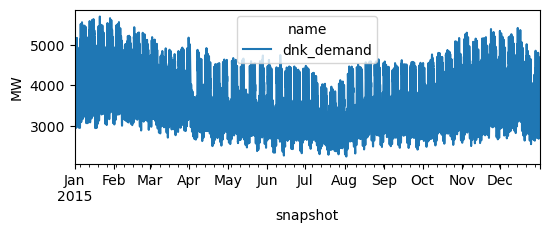

In [10]:
dnk_n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

Generators in Denmark:

In [11]:
# wind onshore
dnk_n.add(
    "Generator",
    "wind_combined", 
    bus = "Denmark", 
    carrier = "wind_combined", 
    capital_cost =  costs.loc["wind_combined", "capital_cost"],
    marginal_cost = costs.loc["wind_combined", "marginal_cost"],
    p_max_pu = CF_wind.values,
    p_nom_extendable = True
    )

In [12]:
# solar
dnk_n.add(
    "Generator",
    "solar", 
    bus = "Denmark", 
    carrier = "solar", 
    capital_cost = costs.loc["solar", "capital_cost"] ,
    marginal_cost = costs.loc["solar", "marginal_cost"],
    p_max_pu = CF_solar.values,
    p_nom_extendable = True
    )

In [13]:
# CCGT
dnk_n.add(
    "Generator",
    "CCGT", 
    bus = "Denmark", 
    carrier = "CCGT", 
    capital_cost = costs.loc["CCGT", "capital_cost"] ,
    marginal_cost = costs.loc["CCGT", "marginal_cost"],
    efficiency = 0.58 ,
    p_nom_extendable = True
    )

<Axes: xlabel='snapshot', ylabel='CF'>

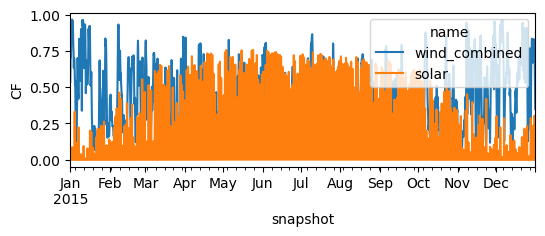

In [14]:
dnk_n.generators_t.p_max_pu.loc["2015"].plot(figsize=(6, 2), ylabel="CF")

Optimize!

In [15]:
dnk_n.optimize(solver_name = "highs")

/var/folders/yq/vlbyk2rd3l18vhbm7rx120fw0000gn/T/ipykernel_7778/2141225146.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 561.00it/s]
INFO:linopy.io: Writing time: 0.18s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-yosu520j has 61323 rows; 26283 cols; 100707 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [6e+01, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+03, 6e+03]
Presolving model
26208 rows, 17451 cols, 56760 nonzeros  0s
Dependent equations search running on 4344 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
26208 rows, 17451 cols, 56760 nonzeros  0s
Presolve reductions: rows 26208(-35115); columns 17451(-8832); nonzeros 56760(-43947) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.95e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      17047     1.9488520816e+09 Pr: 0(0); Du: 0(2.81056e-11) 1.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-yosu520j
Model status        : Optimal
Simplex   iterations: 17047
Objective value     :  1.9488520816e+09
P-D objective error :  1.5903934202e-15
HiGHS run time      :          1.03


('ok', 'optimal')

Results:

In [16]:
#objective value
print("objective value: ", dnk_n.objective)

objective value:  1948852081.6167934


In [17]:
#capacities installed
print("in GW \n", dnk_n.generators.p_nom_opt)

in GW 
 name
wind_combined    5955.083376
solar            2796.854480
CCGT             5340.261575
Name: p_nom_opt, dtype: float64


In [18]:
#hour production for each technology
hourly_prod = dnk_n.generators_t.p
print(hourly_prod)
#dnk_n.generators_t.p.to_csv("hourly_dnk_production.csv")



name                 wind_combined  solar         CCGT
snapshot                                              
2015-01-01 00:00:00    3100.000000   -0.0    -0.000000
2015-01-01 01:00:00    3100.020000   -0.0    -0.000000
2015-01-01 02:00:00    2980.390000   -0.0    -0.000000
2015-01-01 03:00:00    2933.490000   -0.0    -0.000000
2015-01-01 04:00:00    2941.540000   -0.0    -0.000000
...                            ...    ...          ...
2015-12-31 19:00:00    2519.976902   -0.0  1167.893098
2015-12-31 20:00:00    2480.238630   -0.0  1055.311370
2015-12-31 21:00:00    2324.370278   -0.0  1064.889722
2015-12-31 22:00:00    2109.183340   -0.0  1153.086660
2015-12-31 23:00:00    2064.859655   -0.0  1093.990345

[8760 rows x 3 columns]


In [19]:
#annual production for each technology
print(" in TWH \n", dnk_n.generators_t.p.sum()/1e6)


 in TWH 
 name
wind_combined    18.158879
solar             2.767393
CCGT             11.887876
dtype: float64


In [20]:
#hour income for each technology
hourly_income = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy())
print(hourly_income)
#dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy()).to_csv("hourly_dnk_income.csv")


name                 wind_combined  solar          CCGT
snapshot                                               
2015-01-01 00:00:00      -0.000000    0.0      0.000000
2015-01-01 01:00:00      -0.000000    0.0      0.000000
2015-01-01 02:00:00      -0.000000    0.0      0.000000
2015-01-01 03:00:00      -0.000000    0.0      0.000000
2015-01-01 04:00:00      -0.000000    0.0      0.000000
...                            ...    ...           ...
2015-12-31 19:00:00  159694.536229   -0.0  74011.054056
2015-12-31 20:00:00  157176.265204   -0.0  66876.589082
2015-12-31 21:00:00  147298.665050   -0.0  67483.582950
2015-12-31 22:00:00  133661.961393   -0.0  73072.748893
2015-12-31 23:00:00  130853.106119   -0.0  69327.731024

[8760 rows x 3 columns]


In [21]:
#annual income for each technology
incomes_y = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy()).sum()
print(incomes_y)

name
wind_combined    7.592731e+08
solar            1.398427e+08
CCGT             1.049736e+09
dtype: float64


In [22]:
#annual costs for each technology
costs_y = dnk_n.statistics.capex().add(dnk_n.statistics.opex(), fill_value=0)
print(costs_y)

component  carrier      
Generator  CCGT             1.049736e+09
           solar            1.398427e+08
           wind_combined    7.592731e+08
dtype: float64


In [23]:
#hourly energy prices
energy_prices = dnk_n.buses_t.marginal_price
#energy_prices.to_csv("annual_energy_prices_dnk.csv")

In [24]:
#annual scarsity revenue, it should be equal to capex cost for each technology
revenue = dnk_n.statistics.revenue(groupby=False)
opex = dnk_n.statistics.opex(groupby=False)


scarsity_revenue = revenue.sub(opex, fill_value=0)

print(scarsity_revenue.loc["Generator"])

print(dnk_n.statistics.capex())

name
CCGT             2.963845e+08
solar            1.398427e+08
wind_combined    7.592731e+08
dtype: float64
component  carrier      
Generator  CCGT             2.963845e+08
           solar            1.398427e+08
           wind_combined    7.592731e+08
dtype: float64


In [25]:
import importlib
import functions_to_investigate as fti

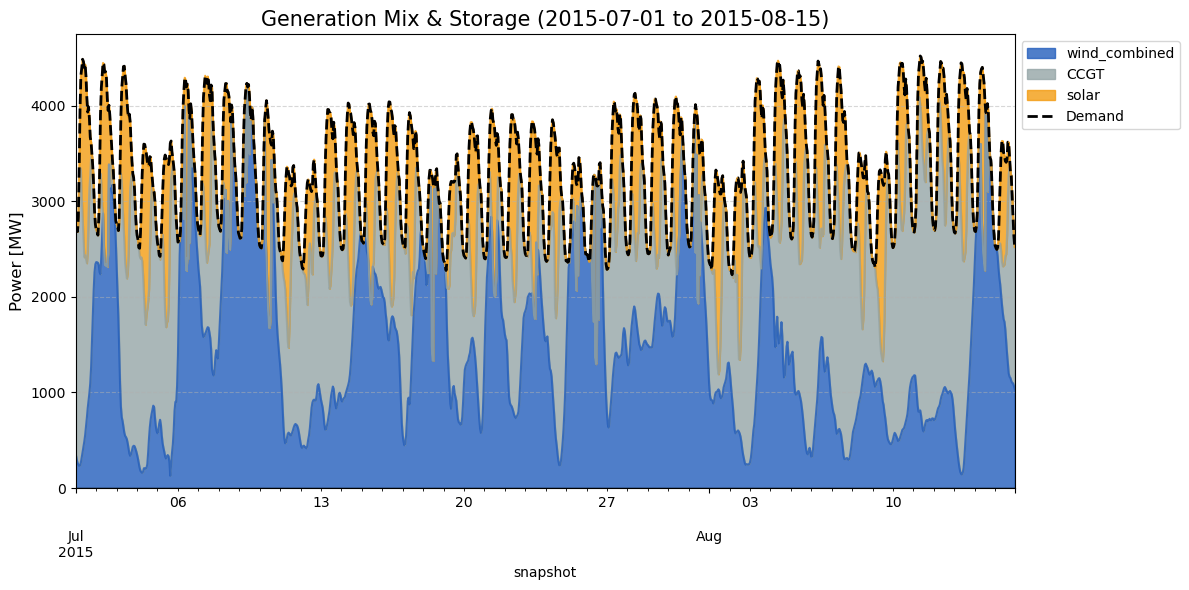

In [26]:
fti.plot_generation_mix(dnk_n, '2015-07-01', '2015-08-15')

In [27]:
fti.calculate_system_metrics(dnk_n, '2015-07-01', '2015-08-31')

------------------------------
METRICS (2015-07-01 to 2015-08-31)
------------------------------
Average Capacity Factors [%]:
  * wind_combined  :  27.38%
  * solar          :  19.44%
  * CCGT           :  22.88%

Total Backup Energy (CCGT): 1.818 TWh
Renewable Share:         64.03%
------------------------------


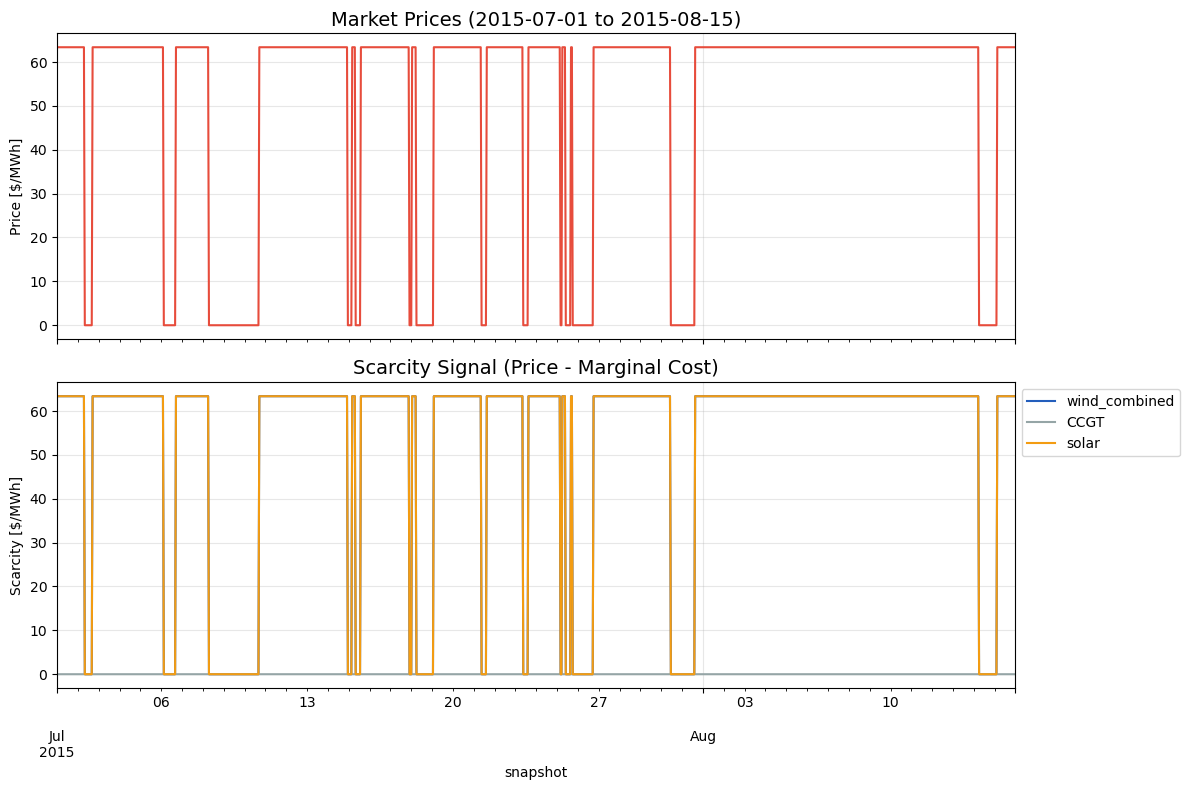

In [28]:
fti.plot_prices_and_scarcity(dnk_n, '2015-07-01', '2015-08-15')

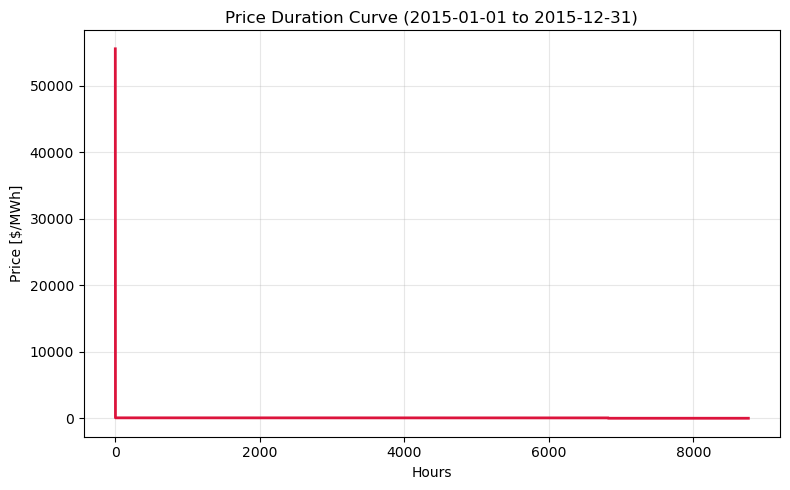

In [29]:
fti.plot_price_duration_curve(dnk_n, '2015-01-01', '2015-12-31')

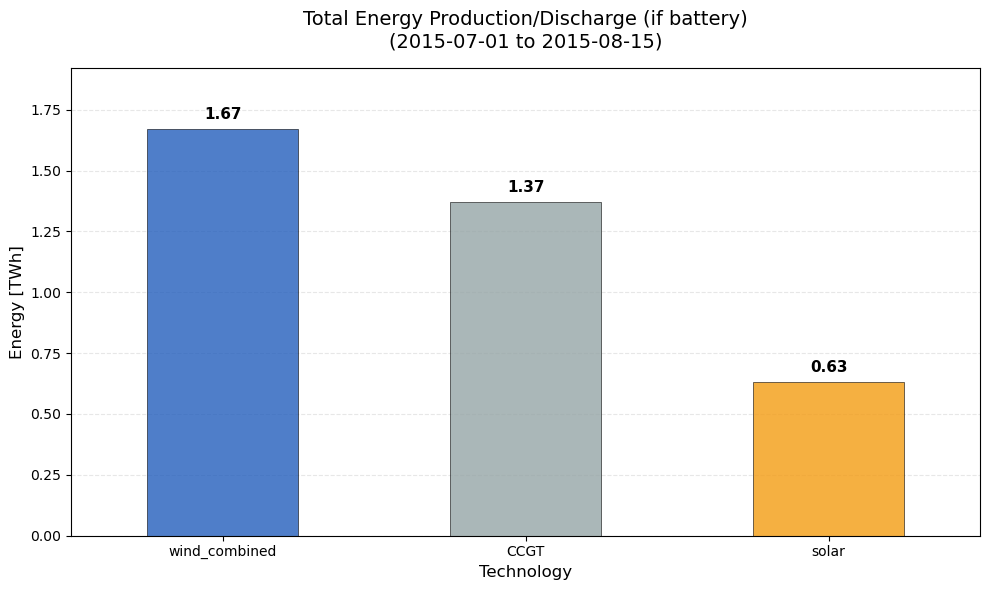

In [30]:
fti.plot_energy_production(dnk_n, '2015-07-01', '2015-08-15')

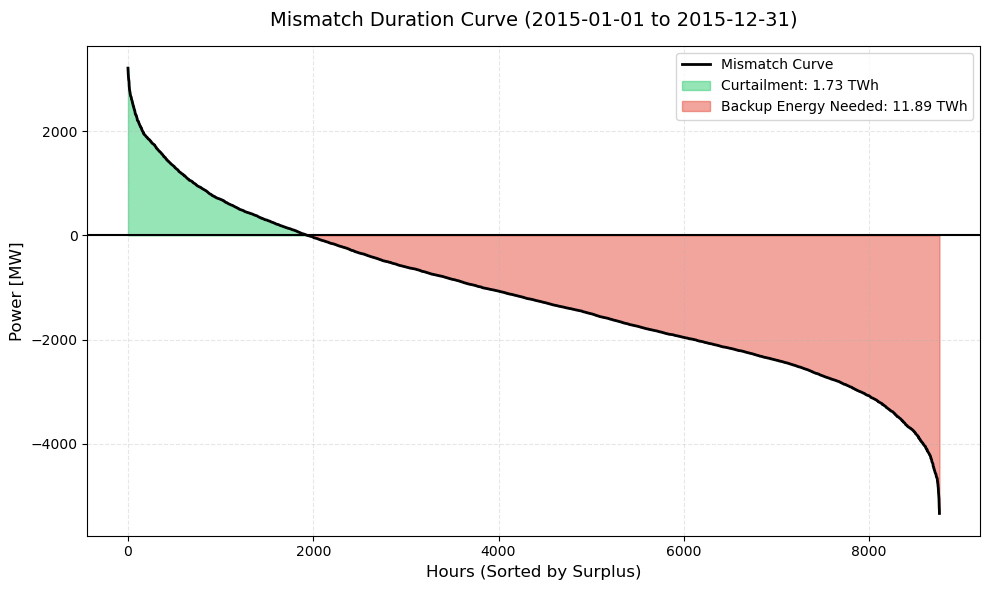

Analysis Results:
 - Total Potential Curtailment: 1.729 TWh
 - Total Backup Energy Needed:  11.888 TWh


In [31]:
fti.plot_mismatch_analysis(dnk_n, '2015-01-01', '2015-12-31')

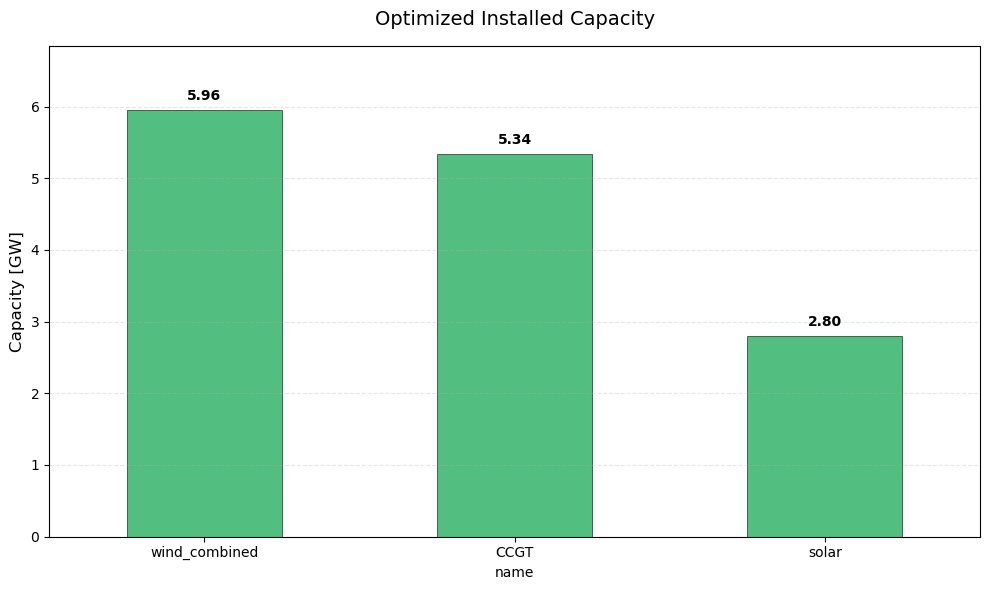

In [32]:
fti.plot_installed_capacity(dnk_n)

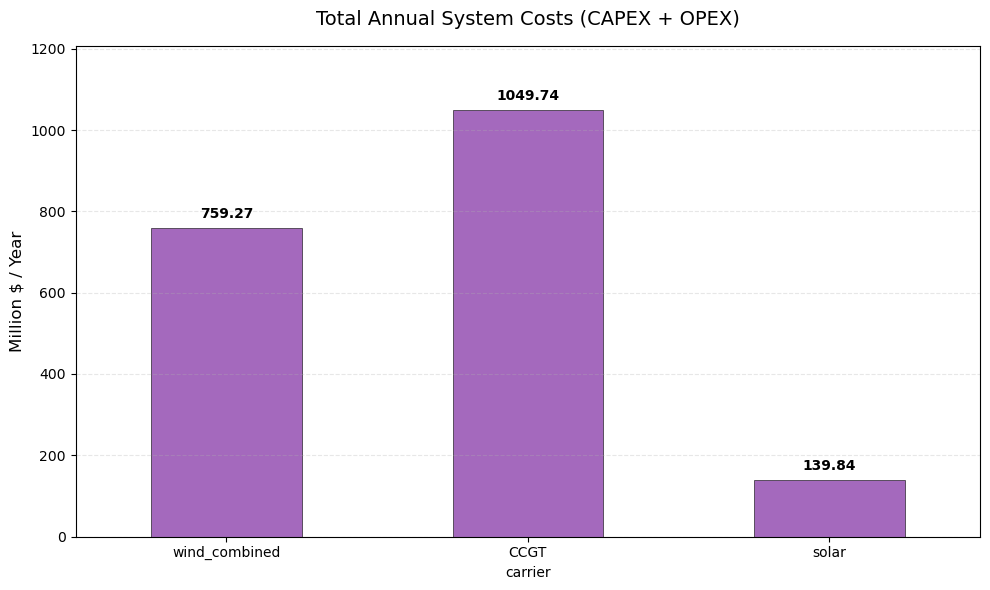

In [33]:
fti.plot_system_costs(dnk_n)